In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("traffic_index.csv")

# Define Saudi Arabian cities
saudi_cities = ['Dammam', 'Jeddah', 'Mecca', 'Medina', 'Riyadh']

# Filter the dataset
saudi_df = df[df['City'].isin(saudi_cities)]

# Save the filtered dataset

saudi_df.to_csv("Dataset.csv", index=False)




In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load the filtered Saudi dataset
df = pd.read_csv("Dataset.csv")
# Step 1: Handling Missing Data
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Step 2: Parse Datetime
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

# Step 3: Normalize numerical columns and create new columns for normalized values
scaler = MinMaxScaler()

# Normalize each numeric column and create new columns
for col in numeric_cols:
    df[col + '_norm'] = scaler.fit_transform(df[[col]])

# Step 4: Check again after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Optional: Save cleaned dataset
df.to_csv("Dataset.csv", index=False)


Missing values before cleaning:
City                     0
Datetime                 0
TrafficIndexLive         0
JamsCount                0
JamsDelay                0
JamsLength               0
TrafficIndexWeekAgo      0
TravelTimeHistoric     773
TravelTimeLive         773
dtype: int64

Missing values after cleaning:
City                        0
Datetime                    0
TrafficIndexLive            0
JamsCount                   0
JamsDelay                   0
JamsLength                  0
TrafficIndexWeekAgo         0
TravelTimeHistoric          0
TravelTimeLive              0
TrafficIndexLive_norm       0
JamsCount_norm              0
JamsDelay_norm              0
JamsLength_norm             0
TrafficIndexWeekAgo_norm    0
TravelTimeHistoric_norm     0
TravelTimeLive_norm         0
dtype: int64


=== Descriptive Statistics ===
       TrafficIndexLive     JamsCount     JamsDelay    JamsLength  \
count      24148.000000  24148.000000  24148.000000  24148.000000   
mean          13.923141     69.330752    284.876155     60.231912   
std           15.368228    101.853423    474.446559    101.298459   
min            0.000000      0.000000      0.000000      0.000000   
25%            1.000000      7.000000     24.600000      2.500000   
50%            8.000000     23.000000     80.400000     11.400000   
75%           23.000000     88.000000    325.925000     71.200000   
max           99.000000    883.000000   5466.300000    932.900000   

       TrafficIndexWeekAgo  TravelTimeHistoric  TravelTimeLive  \
count         24148.000000        24148.000000    24148.000000   
mean             13.819033           69.983363       69.173648   
std              15.313244            7.211878       10.882399   
min               0.000000           50.711780       48.845588   
25%              

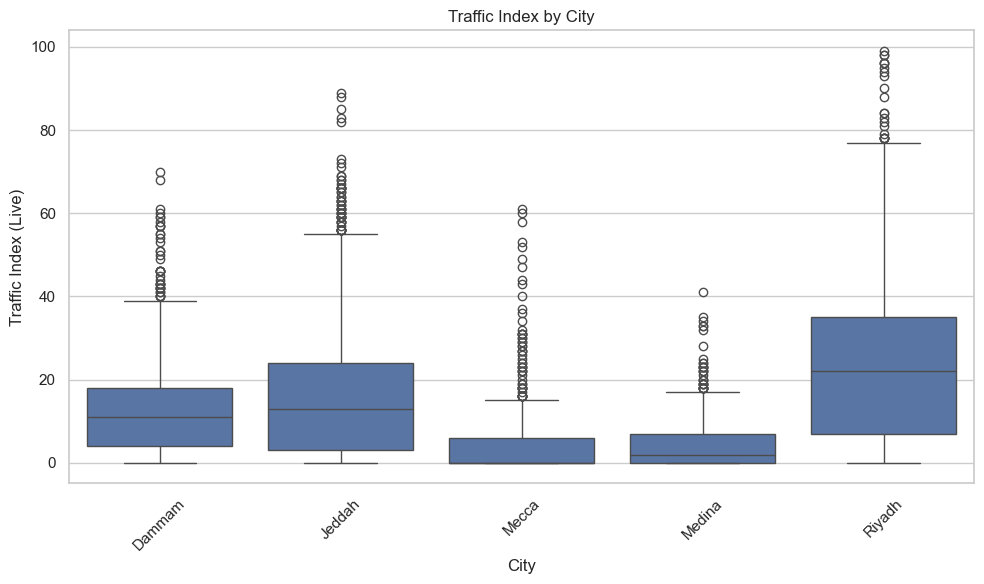

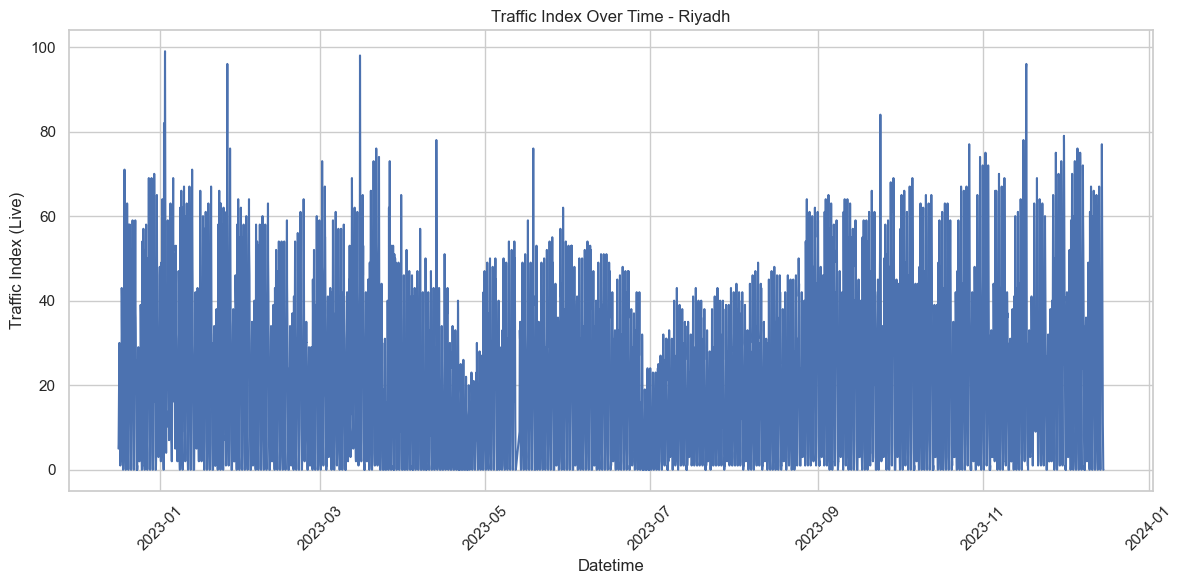

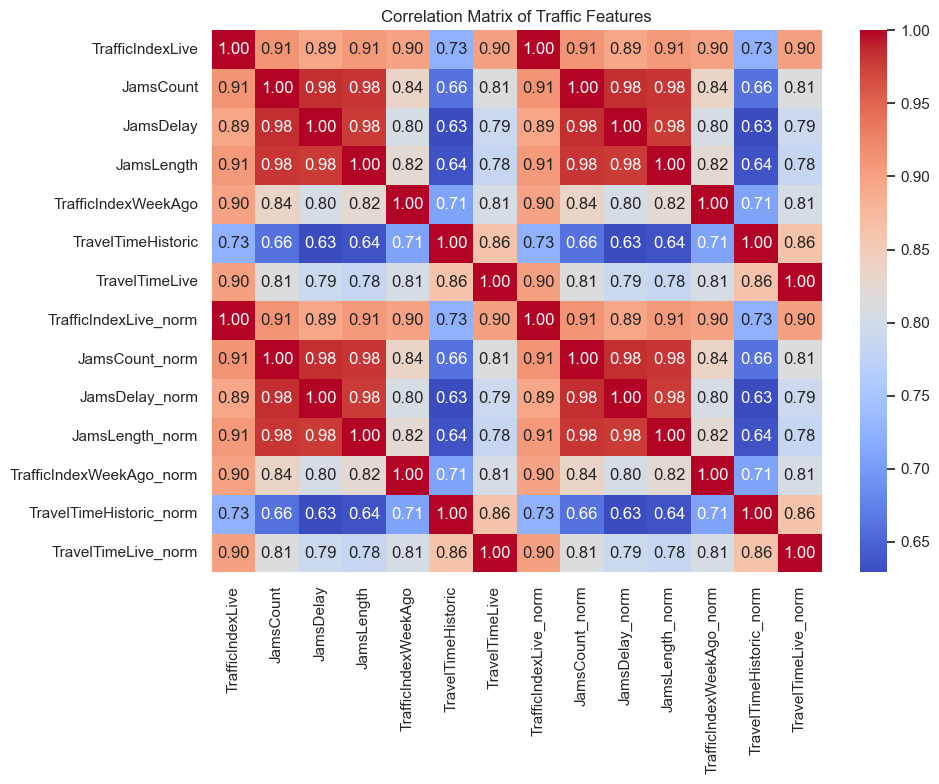

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load the cleaned dataset
df = pd.read_csv("Dataset.csv")

# --- 1. Descriptive Statistics ---
print("=== Descriptive Statistics ===")
print(df.describe())

# --- 2. Identify Patterns and Outliers ---

# Detect potential outliers using z-scores for numerical columns
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number]), nan_policy='omit'))
outliers = (z_scores > 3).sum(axis=0)
print("\n=== Outlier Detection (Z-score > 3) ===")
print(outliers)

# --- 3. Handling Missing Data & Data Quality Issues ---
print("\n=== Missing Data Summary ===")
print(df.isnull().sum())

# If there are missing datetime values, drop them (they likely failed parsing)
df = df.dropna(subset=['Datetime'])

# Make sure your datetime column is actual datetimes
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Now create a DataFrame for Riyadh
riyadh_df = df[df['City'] == 'Riyadh']

# --- 4. Hypothesis Formulation Example ---
# Hypothesis: Traffic congestion in Riyadh is higher than in other cities




# What Was the Null Hypothesis?
# 🎯 We Tested:
# Does Riyadh have significantly different (likely higher) traffic congestion than other Saudi cities?

# We used an independent two-sample t-test comparing:

# Group 1: TrafficIndexLive values in Riyadh

# Group 2: TrafficIndexLive values in other cities




riyadh_congestion = df[df['City'] == 'Riyadh']['TrafficIndexLive']
other_cities_congestion = df[df['City'] != 'Riyadh']['TrafficIndexLive']

# Null Hypothesis: No difference in mean traffic index
# Alternate Hypothesis: Riyadh has higher traffic congestion

# --- 5. Inferential Technique: Independent T-test ---
t_stat, p_val = stats.ttest_ind(riyadh_congestion, other_cities_congestion, equal_var=False)

print("\n=== T-Test: Riyadh vs Other Cities (TrafficIndexLive) ===")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")
if p_val < 0.05:
    print("→ Reject the null hypothesis: Riyadh has significantly different traffic congestion.")
else:
    print("→ Fail to reject the null hypothesis: No significant difference found.")

# --- Visualizations to Support Findings ---

# Set up for clean plotting
sns.set(style="whitegrid")

# 1. Boxplot to compare traffic congestion across cities
# 1. Boxplot to compare traffic congestion across cities
plt.figure(figsize=(10, 6))
sns.boxplot(x='City', y='TrafficIndexLive', data=df)
plt.title("Traffic Index by City")
plt.ylabel("Traffic Index (Live)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("boxplot_traffic_by_city.png")  # 💾 Save the plot
plt.show()


# 2. Time-series plot for traffic trend in Riyadh
# 2. Time-series plot for traffic trend in Riyadh
plt.figure(figsize=(12, 6))
sns.lineplot(x='Datetime', y='TrafficIndexLive', data=riyadh_df)
plt.title("Traffic Index Over Time - Riyadh")
plt.ylabel("Traffic Index (Live)")
plt.xlabel("Datetime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("riyadh_traffic_timeseries.png")  # 💾 Save the plot
plt.show()


# 3. Heatmap of correlation between numeric features
# 3. Heatmap of correlation between numeric features
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Traffic Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")  # 💾 Save the plot
plt.show()



In [6]:

import pandas as pd

# Load your dataset
df = pd.read_csv("Dataset.csv")

# Convert to datetime format (if not already)
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Split the date into components
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day_name()
df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['Second'] = df['Datetime'].dt.second

df['IsWeekend'] = df['Day'].isin(['Friday', 'Saturday'])


# Save updated DataFrame
df.to_csv("Dataset.csv", index=False)

# Show a preview of the new columns
print(df[['Datetime', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']].head())



             Datetime  Year  Month     Day  Hour  Minute  Second
0 2023-07-07 08:16:30  2023      7  Friday     8      16      30
1 2023-07-07 09:01:30  2023      7  Friday     9       1      30
2 2023-07-07 10:01:30  2023      7  Friday    10       1      30
3 2023-07-07 11:01:30  2023      7  Friday    11       1      30
4 2023-07-07 12:46:30  2023      7  Friday    12      46      30


In [7]:
# K-means


import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load dataset
dataset = pd.read_csv('Dataset.csv')

# Selecting relevant features for clustering
X = dataset[['TrafficIndexLive', 'JamsCount', 'JamsDelay', 'TravelTimeLive']]

# Scaling the data (important for K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the first few rows of the scaled data
print(X_scaled[:5])


[[-0.71077594 -0.63161435 -0.56546244 -1.1137534 ]
 [-0.71077594 -0.65125082 -0.57389349 -1.03472609]
 [-0.77584659 -0.67088729 -0.59476034 -1.21121981]
 [-0.84091725 -0.64143259 -0.57262884 -1.29425109]
 [-0.71077594 -0.63161435 -0.55934993 -0.59836478]]


In [9]:
# Apply KMeans clustering with 3 clusters (Low, Moderate, High)
kmeans = KMeans(n_clusters=3, random_state=42)
dataset['Cluster'] = kmeans.fit_predict(X_scaled)

# Check the first few rows of the dataset with cluster labels
print(dataset[['City', 'TrafficIndexLive', 'JamsCount', 'JamsDelay', 'TravelTimeLive', 'Cluster']].head())


     City  TrafficIndexLive  JamsCount  JamsDelay  TravelTimeLive  Cluster
0  Dammam                 3          5       16.6       57.053590        0
1  Dammam                 3          3       12.6       57.913579        0
2  Dammam                 2          1        2.7       55.992944        0
3  Dammam                 1          4       13.2       55.089383        0
4  Dammam                 3          5       19.5       62.662138        0


In [10]:
# Get the cluster centroids
centroids = kmeans.cluster_centers_

# Inverse transform the scaled centroids to original scale
centroids_original = scaler.inverse_transform(centroids)

# Print the centroids
print("Cluster centroids (in original scale):")
print(centroids_original)


Cluster centroids (in original scale):
[[   4.9416888    16.64574711   58.72467107   63.43001131]
 [  49.47276465  342.33350462 1583.05775951   91.75166234]
 [  26.59920173  122.82388159  473.61804424   77.33046028]]


In [11]:
# Map the clusters to congestion levels based on their centroids
# Assuming: 
# - Cluster 0: Low Congestion (lowest TrafficIndexLive and JamsDelay)
# - Cluster 1: Moderate Congestion (intermediate TrafficIndexLive and JamsDelay)
# - Cluster 2: High Congestion (highest TrafficIndexLive and JamsDelay)

cluster_labels = {0: 'Low', 1: 'Moderate', 2: 'High'}

# Assign the corresponding label to each cluster
dataset['CongestionLevel'] = dataset['Cluster'].map(cluster_labels)

# Check the final dataset with the congestion levels
print(dataset[['City', 'TrafficIndexLive', 'JamsCount', 'JamsDelay', 'TravelTimeLive', 'CongestionLevel']].head())


df.to_csv("Dataset.csv", index=False)

     City  TrafficIndexLive  JamsCount  JamsDelay  TravelTimeLive  \
0  Dammam                 3          5       16.6       57.053590   
1  Dammam                 3          3       12.6       57.913579   
2  Dammam                 2          1        2.7       55.992944   
3  Dammam                 1          4       13.2       55.089383   
4  Dammam                 3          5       19.5       62.662138   

  CongestionLevel  
0             Low  
1             Low  
2             Low  
3             Low  
4             Low  


In [12]:
def calculate_congestion_level(row):
    if row['TrafficIndexLive'] > 4 or row['JamsDelay'] > 15 or row['JamsCount'] > 5:
        return 'High'
    elif 2 <= row['TrafficIndexLive'] <= 4 or 5 <= row['JamsDelay'] <= 15 or 2 <= row['JamsCount'] <= 5:
        return 'Moderate'
    else:
        return 'Low'


import pandas as pd

# Load your dataset
df = pd.read_csv("dataset.csv")

# Apply the function to each row to calculate the congestion level
df['CongestionLevel'] = df.apply(calculate_congestion_level, axis=1)

# Check the first few rows to ensure the congestion levels are calculated
print(df[['City', 'Datetime', 'TrafficIndexLive', 'JamsCount', 'JamsDelay', 'CongestionLevel']].head())

df.to_csv("dataset.csv", index=False)


     City             Datetime  TrafficIndexLive  JamsCount  JamsDelay  \
0  Dammam  2023-07-07 08:16:30                 3          5       16.6   
1  Dammam  2023-07-07 09:01:30                 3          3       12.6   
2  Dammam  2023-07-07 10:01:30                 2          1        2.7   
3  Dammam  2023-07-07 11:01:30                 1          4       13.2   
4  Dammam  2023-07-07 12:46:30                 3          5       19.5   

  CongestionLevel  
0            High  
1        Moderate  
2        Moderate  
3        Moderate  
4            High  
